In [238]:
from pathlib import Path
import subprocess

subprocess.run([
    "scp milkv@192.168.50.195:~/sophgo/smokewagon-benchmarks/result-* ~/sophgo/smokewagon-benchmarks/"],
    shell=True, check=True)

CompletedProcess(args=['scp milkv@192.168.50.195:~/sophgo/smokewagon-benchmarks/result-* ~/sophgo/smokewagon-benchmarks/'], returncode=0)

In [240]:
hash_names = {
    "24ac9404254c0ee7cccd53821e73af8c81fb9a46" : "xarray",
    "c277100ed866fc7f3cfae0b6172c5d3ed2ab5bb0" : "flat1GB",
    "eadff10a39c6faf2e486ed108e3a3bc4c2bb77b3" : "baseline",
}

import pandas as pd
import matplotlib.pyplot as plt

prefix = "result-microbenchmark-filebacked-6.9.0-"
suffix = ".csv"
result_files = Path("~/sophgo/smokewagon-benchmarks").expanduser().glob(prefix + "*" + suffix)
dfs = []

for f in result_files:
    df = pd.read_csv(f, index_col=0)

    # column name faff
    label = f.name[len(prefix):-len(suffix)].split("-")
    col_label = tuple([label[1], hash_names.get(label[2])])
    df.columns = pd.MultiIndex.from_tuples([col_label])

    dfs.append(df)

df = pd.concat(dfs, axis=1)
df

inactive                  smokewagon       
          xarray flat1GB baseline    flat1GB xarray
threads                                            
1         149011  144507   144979      58807  57415
2          92441   90864    93987      96547  98219
3          83292   83419    86117      74205  74482
4          78043   79384    80740      73046  73421
5          76835   77741    79260      72183  72186
...          ...     ...      ...        ...    ...
60         31020   30980    31605      65437  63587
61         30804   30777    31369      60140  62096
62         30490   30430    31087      63719  65082
63         29986   29925    30580      64417  65580
64         29562   29554    30132      64230  64466

[64 rows x 5 columns]

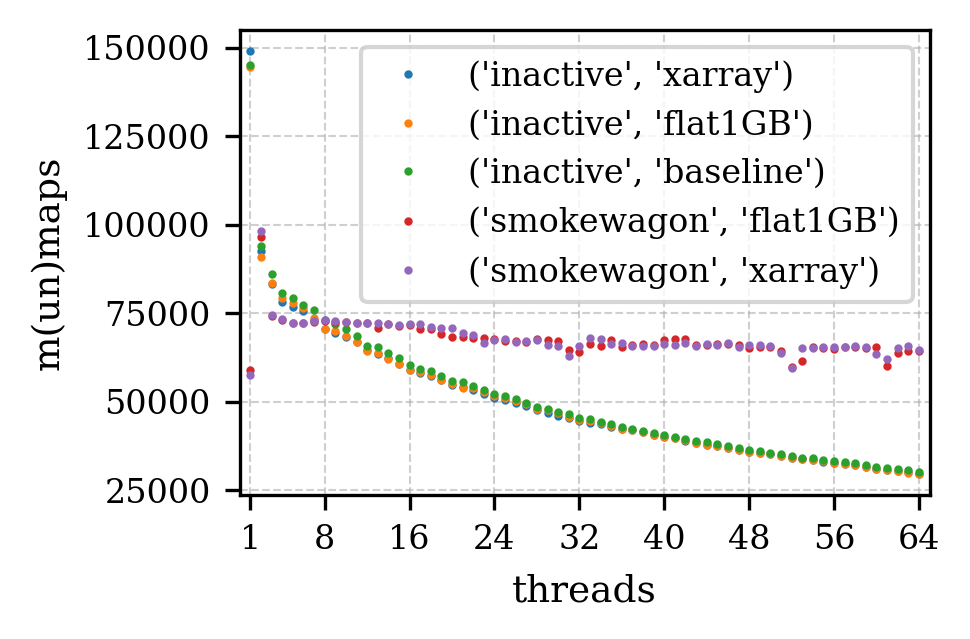

In [241]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(3.3, 2.2))  # ACM single-column width
ax.plot(df.index, df.values, '.', markersize=2)
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(df.columns, frameon=True)
plt.tight_layout()
plt.savefig("microbenchmark-filebacked.pdf", bbox_inches="tight")